In [1]:
import pandas as pd
import sys
import os
import re

In [2]:
# create a dict in which the key is the prob in [0...1, step 0.2] and the value is the log file in the saved_logs folder
prob_to_logfile = {0.0: '../saved_logs/Seed_505_p_0.0.log', 
                   0.2: '../saved_logs/Seed_505_p_0.2.log',
                   0.4: '../saved_logs/Seed_505_p_0.4.log',
                   0.6: '../saved_logs/Seed_505_p_0.6.log',
                   0.8: '../saved_logs/Seed_505_p_0.8.log',
                   1.0: '../saved_logs/Seed_505_p_1.0.log'}
# create a dict in which the key is the prob in [0...1, step 0.2] and the value is the dataframe
prob_to_df = {}


In [3]:
import re
import pandas as pd

for p_value, file_log in prob_to_logfile.items():
    with open(file_log, 'r') as file:
        lines = file.readlines()

    epoch_data = {}

    for line in lines:
        # Total active users
        match_active = re.search(r"step \d+, epoch (\d+): (\d+) active users", line)
        if match_active:
            epoch = int(match_active.group(1))
            users = int(match_active.group(2))
            if epoch not in epoch_data:
                epoch_data[epoch] = {
                    'Total_Active_users': 0,
                    'Return_count': 0,
                    'Explore_count': 0,
                    'Rec_count': 0,
                    'strange_return': 0,
                    'strange_explore': 0,
                    'strange_recommender': 0
                }
            epoch_data[epoch]['Total_Active_users'] += users

        # User state lines (counting events, not unique users)
        match_state = re.search(r"User \d+ - Epoch (\d+) - State (\w+)", line)
        if match_state:
            epoch = int(match_state.group(1))
            state = match_state.group(2).lower()

            if epoch not in epoch_data:
                epoch_data[epoch] = {
                    'Total_Active_users': 0,
                    'Return_count': 0,
                    'Explore_count': 0,
                    'Rec_count': 0,
                    'strange_return': 0,
                    'strange_explore': 0,
                    'strange_recommender': 0
                }

            if state == 'return':
                epoch_data[epoch]['Return_count'] += 1
            elif state == 'explore':
                epoch_data[epoch]['Explore_count'] += 1
            elif state == 'rec':
                epoch_data[epoch]['Rec_count'] += 1

        # Strange counts
        match_strange = re.search(r"Epoch (\d+): strange return: (\d+), strange explore: (\d+), strange recommender: (\d+)", line)
        if match_strange:
            epoch = int(match_strange.group(1))
            if epoch not in epoch_data:
                epoch_data[epoch] = {
                    'Total_Active_users': 0,
                    'Return_count': 0,
                    'Explore_count': 0,
                    'Rec_count': 0,
                    'strange_return': 0,
                    'strange_explore': 0,
                    'strange_recommender': 0
                }

            epoch_data[epoch]['strange_return'] = int(match_strange.group(2))
            epoch_data[epoch]['strange_explore'] = int(match_strange.group(3))
            epoch_data[epoch]['strange_recommender'] = int(match_strange.group(4))

    # Create structured DataFrame
    records = []
    for epoch, data in epoch_data.items():
        total_users = data['Total_Active_users']
        n_return = data['Return_count']
        n_explore = data['Explore_count']
        n_rec = data['Rec_count']

        sr = data['strange_return']
        se = data['strange_explore']
        srec = data['strange_recommender']

        row = {
            'epoch': epoch,
            'Total_Active_users': total_users,
            'Return_count': n_return,
            'Explore_count': n_explore,
            'Rec_count': n_rec,
            'strange_return_total_pct': (sr / total_users) * 100 if total_users else 0,
            'strange_explore_total_pct': (se / total_users) * 100 if total_users else 0,
            'strange_recommender_total_pct': (srec / total_users) * 100 if total_users else 0,
            'strange_return_returner_pct': (sr / n_return) * 100 if n_return else 0,
            'strange_explore_explorer_pct': (se / n_explore) * 100 if n_explore else 0,
            'strange_recommender_recommender_pct': (srec / n_rec) * 100 if n_rec else 0,
        }

        records.append(row)

    df = pd.DataFrame(records)
    df = df[df['epoch'] != 14]  # remove epoch 14
    df = df.sort_values(by='epoch').reset_index(drop=True)
    prob_to_df[p_value] = df


In [4]:
prob_to_df[0.8]

,epoch,Total_Active_users,Return_count,Explore_count,Rec_count,strange_return_total_pct,strange_explore_total_pct,strange_recommender_total_pct,strange_return_returner_pct,strange_explore_explorer_pct,strange_recommender_recommender_pct
0,0,933,213,80,1133,0.428725,0.107181,0.0,1.877934,1.250000,0.0
1,1,1543,381,136,2015,0.453662,0.129618,0.0,1.837270,1.470588,0.0
2,2,1342,301,118,1683,0.819672,0.149031,0.0,3.654485,1.694915,0.0
3,3,1712,407,162,2330,0.817757,0.233645,0.0,3.439803,2.469136,0.0
4,4,1577,375,127,1945,0.951173,0.380469,0.0,4.000000,4.724409,0.0
5,5,1955,508,165,2724,0.971867,0.358056,0.0,3.740157,4.242424,0.0
6,6,1681,423,135,2228,1.368233,0.416419,0.0,5.437352,5.185185,0.0
7,7,1274,321,107,1665,2.040816,0.784929,0.0,8.099688,9.345794,0.0
8,8,944,230,79,1164,2.754237,1.059322,0.0,11.304348,12.658228,0.0
9,9,1436,311,112,1856,1.949861,0.766017,0.0,9.003215,9.821429,0.0


In [8]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.cm as cm
import numpy as np

def plot_strange_metric(column_name, prob_to_df, save_path=None):
    fig, ax = plt.subplots(figsize=(9, 9), dpi=150)

    # Auto-pretty axis label
    #axis_name = column_name.replace("_", " ").replace("pct", "(%)").title()
    if column_name == "strange_return_total_pct":
        axis_name = "Strange Return over Total users (%)"
    elif column_name == "strange_return_returner_pct":
        axis_name = "Fallback Return (%)"
    elif column_name == "strange_explore_explorer_pct":
        axis_name = "Fallback Explore (%)"
    elif column_name == "strange_explore_total_pct":
        axis_name = "Strange Explore over Total users (%)"

    # Sorted probabilities and inferno color map
    sorted_probs = sorted(prob_to_df.keys())
    n_probs = len(sorted_probs)
    positions = np.linspace(0.1, 1, n_probs)
    positions = np.linspace(0.1, 1, n_probs).astype(float)
    inferno_colors = cm.inferno_r(positions)


    # Plot each probability
    for i, p_value in enumerate(sorted_probs):
        df = prob_to_df[p_value]
        ax.plot(df['epoch'].to_numpy(), df[column_name].to_numpy(), 
                label=fr'$p = {p_value}$', 
                linewidth=3,
                marker='o',
                markersize=12,
                color=inferno_colors[i])

    # Labels and formatting
    #ax.set_title(axis_name, fontsize=30, fontweight='bold', pad=20)
    ax.set_xlabel("Epoch", fontsize=26)
    ax.set_ylabel(axis_name, fontsize=26)
    ax.set_xticks(df['epoch'])
    ax.tick_params(axis='both', which='major', labelsize=22)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_aspect('auto')

    # Remove spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Legend
    ax.legend(fontsize=20, loc='best', frameon=False)

    # Save/show
    plt.tight_layout(pad=3)
    if save_path:
        safe_name = column_name.replace("/", "_")
        plt.savefig(f"{save_path}/{safe_name}.pdf", bbox_inches='tight', dpi=300)
    plt.show()


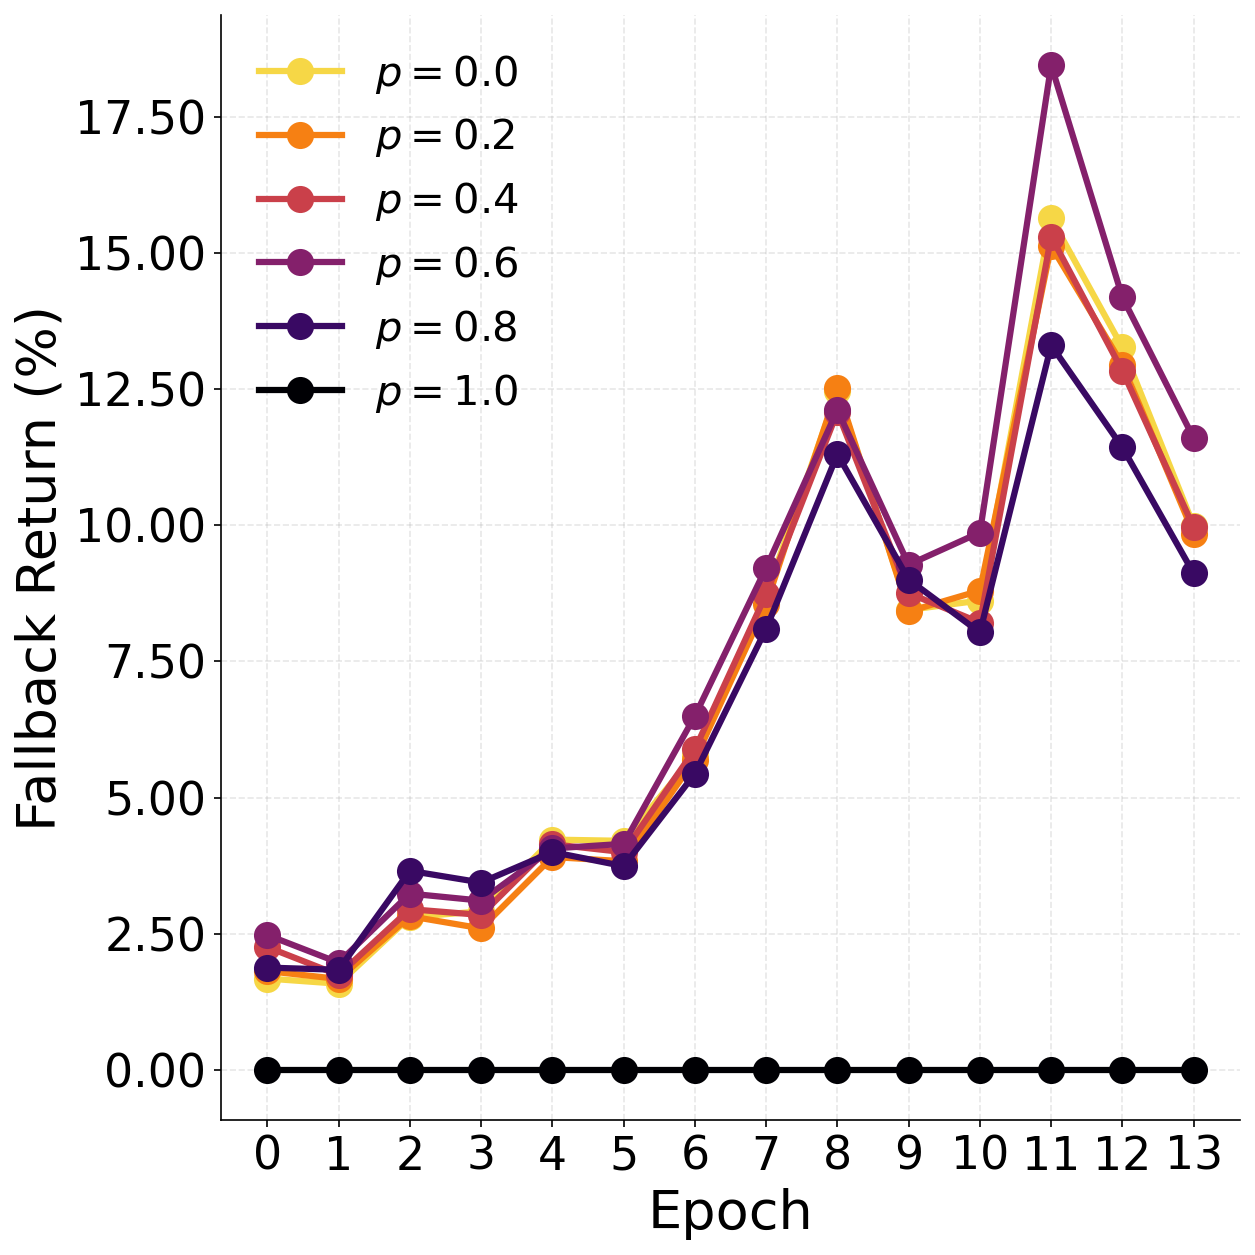

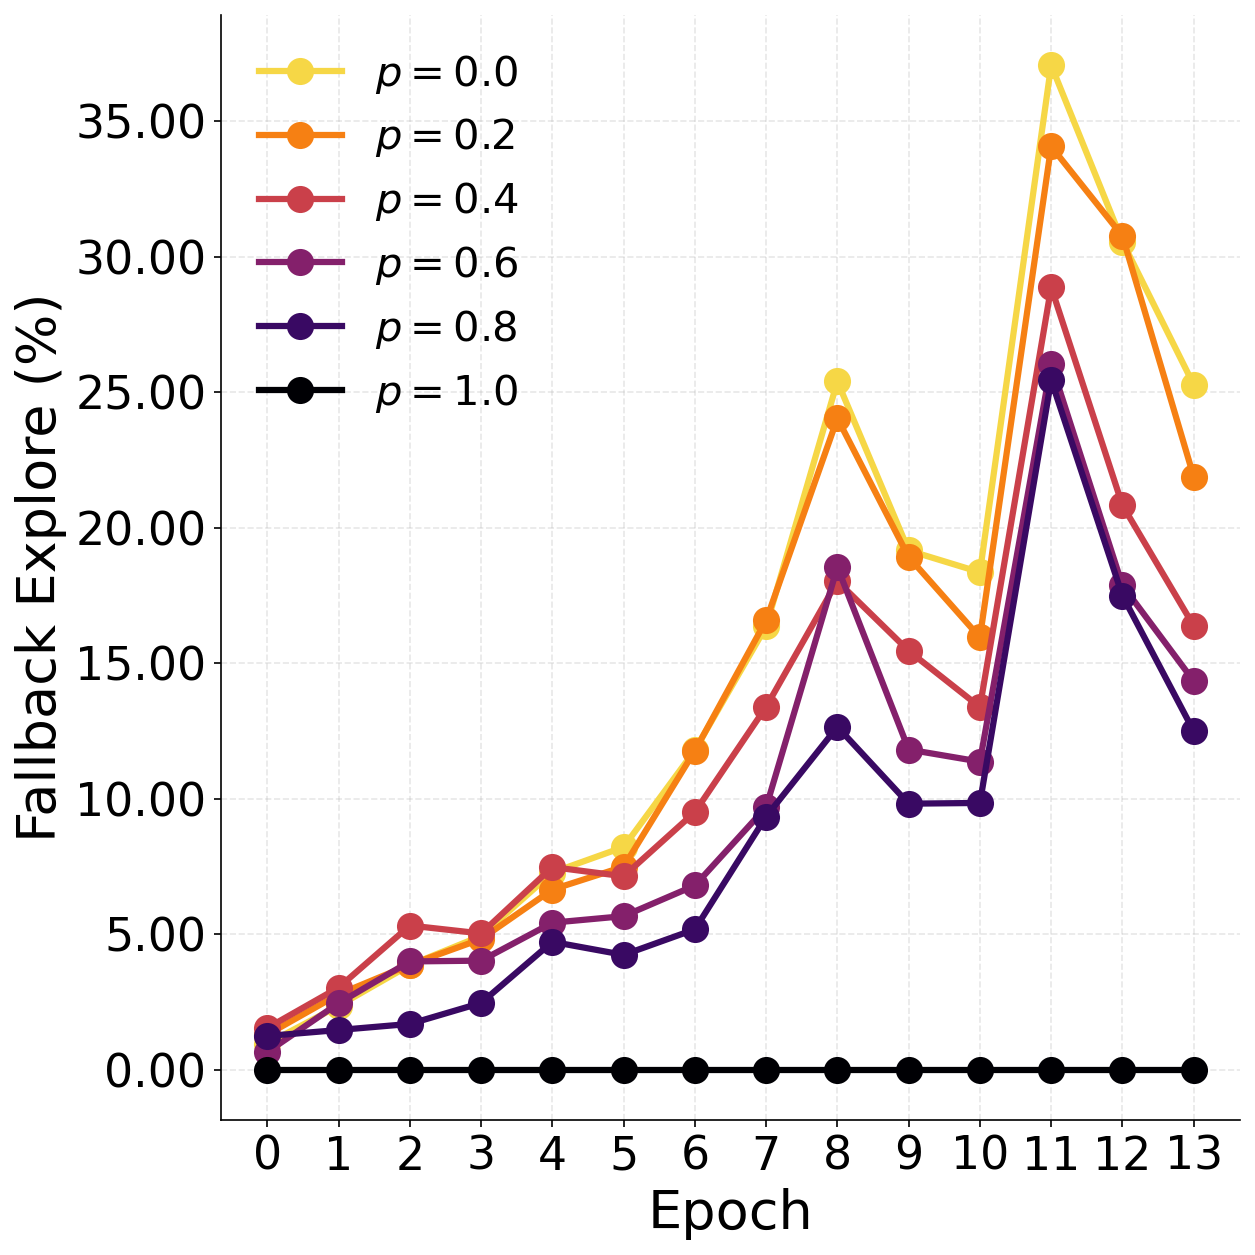

In [9]:
plot_strange_metric('strange_return_returner_pct', prob_to_df, save_path='figures')
plot_strange_metric('strange_explore_explorer_pct', prob_to_df, save_path='figures')

In [7]:
stop

NameError: name 'stop' is not defined

In [ ]:
for p_value, file_log in prob_to_logfile.items():
    with open(file_log, 'r') as file:
        lines = file.readlines()
    epoch_data = {}

    for line in lines:
        epoch_summary = re.search(r"Epoch (\d+): strange return: (\d+), strange explore: (\d+), strange recommender: (\d+)", line)
        if epoch_summary:
            epoch = int(epoch_summary.group(1))
            if epoch not in epoch_data:
                epoch_data[epoch] = {
                    'Total_Active_users': 0,
                    'strange_return': 0,
                    'strange_explore': 0,
                    'strange_recommender': 0
                }
            epoch_data[epoch]['strange_return'] = int(epoch_summary.group(2))
            epoch_data[epoch]['strange_explore'] = int(epoch_summary.group(3))
            epoch_data[epoch]['strange_recommender'] = int(epoch_summary.group(4))
        else:
            step_data = re.search(r"step \d+, epoch (\d+): (\d+) active users", line)
            if step_data:
                epoch = int(step_data.group(1))
                users = int(step_data.group(2))
                if epoch not in epoch_data:
                    epoch_data[epoch] = {
                        'Total_Active_users': 0,
                        'strange_return': 0,
                        'strange_explore': 0,
                        'strange_recommender': 0
                    }
                epoch_data[epoch]['Total_Active_users'] += users


    # Create DataFrame
    df = pd.DataFrame.from_dict(epoch_data, orient='index').reset_index().rename(columns={'index': 'epoch'})

    # Convert strange metrics to percentages
    df['strange_return'] = (df['strange_return'] / df['Total_Active_users']) * 100
    df['strange_explore'] = (df['strange_explore'] / df['Total_Active_users']) * 100
    df['strange_recommender'] = (df['strange_recommender'] / df['Total_Active_users']) * 100

    # Round for readability
    #df = df.round(2)

    # Store in the dict
    prob_to_df[p_value] = df


In [ ]:
prob_to_df[0]

,epoch,Total_Active_users,strange_return,strange_explore,strange_recommender
0,0,933,1.822079,0.428725,0.0
1,1,1543,1.944264,0.972132,0.0
2,2,1342,3.204173,1.639344,0.0
3,3,1712,3.621495,2.219626,0.0
4,4,1577,4.755866,3.107166,0.0
5,5,1955,5.370844,3.785166,0.0
6,6,1681,7.257585,4.759072,0.0
7,7,1274,10.596546,6.985871,0.0
8,8,944,14.512712,10.063559,0.0
9,9,1436,10.027855,7.660167,0.0


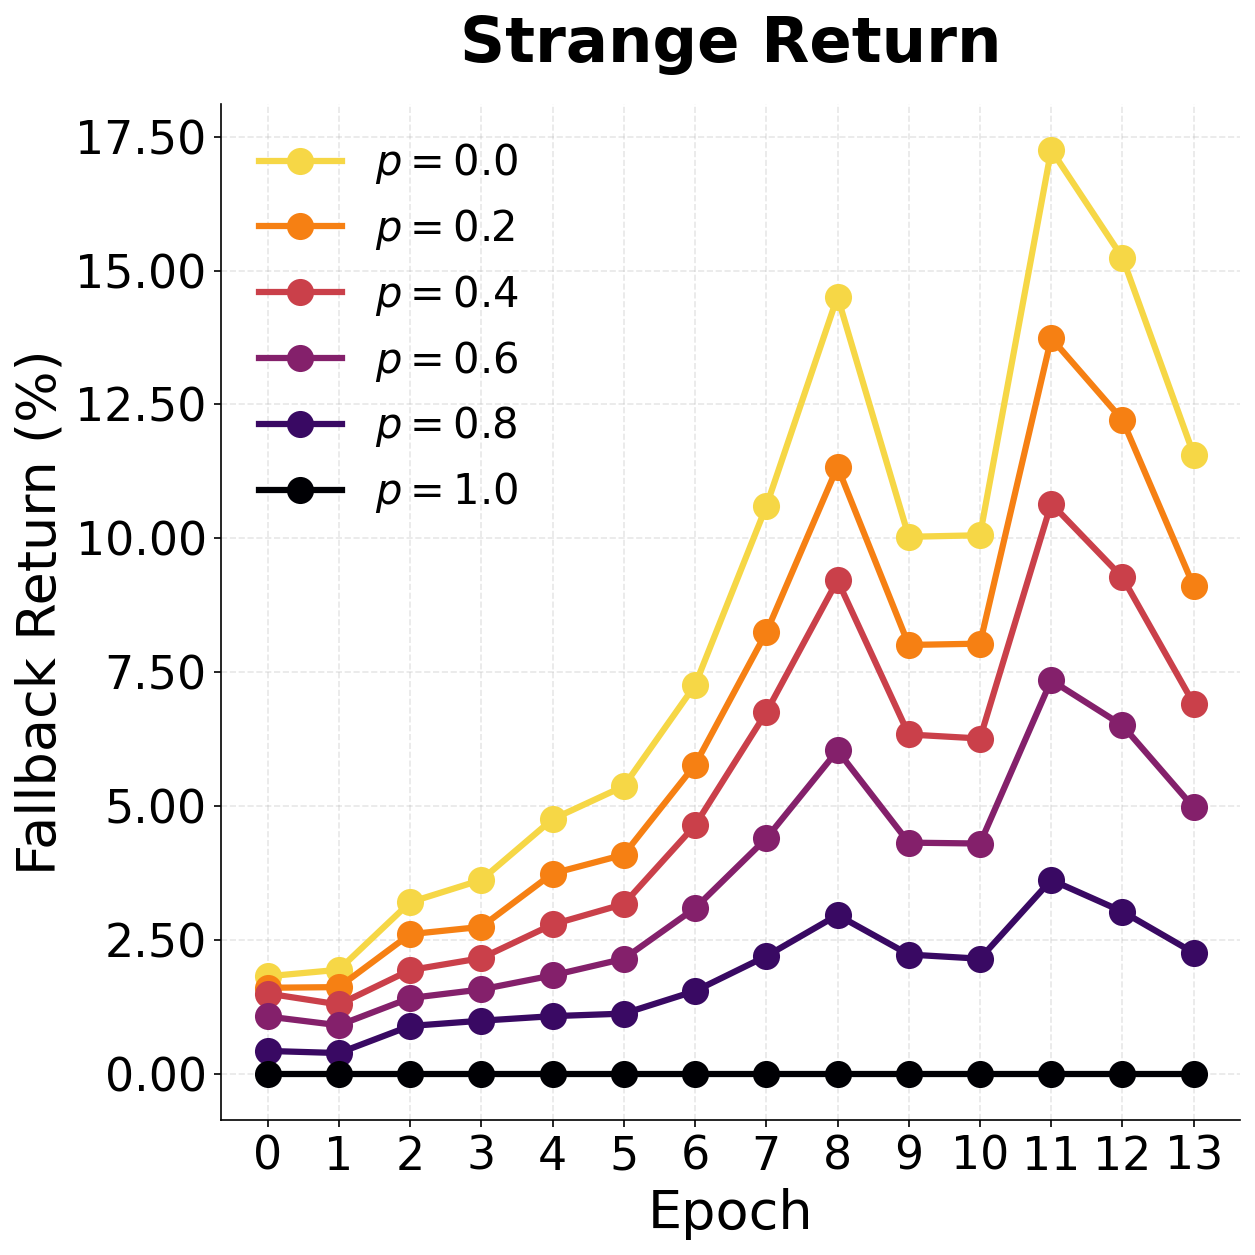

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.cm as cm
import numpy as np

def plot_strange_metric(metric_name, prob_to_df, save_path=None):
    fig, ax = plt.subplots(figsize=(9, 9), dpi=150)

    if metric_name == "strange_return":
        axis_name = "Fallback Return (%)"

    # Sorted probabilities and inferno color map
    sorted_probs = sorted(prob_to_df.keys())
    n_probs = len(sorted_probs)
    positions = np.linspace(0.1, 1, n_probs)  # full inferno range
    inferno_colors = cm.inferno_r(positions)

    # Plot time series per probability
    for i, p_value in enumerate(sorted_probs):
        df = prob_to_df[p_value]
        ax.plot(df['epoch'], df[metric_name], 
                label=fr'$p = {p_value}$', 
                linewidth=3,
                marker='o',
                markersize=12,
                color=inferno_colors[i])

    # Labels and formatting
    ax.set_title(metric_name.replace("_", " ").title(), fontsize=30, fontweight='bold', pad=20)
    ax.set_xlabel("Epoch", fontsize=26)
    ax.set_ylabel(axis_name, fontsize=26)
    ax.set_xticks(df['epoch'])
    ax.tick_params(axis='both', which='major', labelsize=22)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_aspect('auto')

    # remove the top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Legend
    ax.legend(fontsize=20, loc='best', frameon=False)

    # Final layout
    plt.tight_layout(pad=3)
    if save_path:
        plt.savefig(f"{save_path}/{metric_name}.pdf", bbox_inches='tight', dpi=300)
    plt.show()

# Usage: only two metrics
plot_strange_metric('strange_return', prob_to_df, save_path='figures/')
#plot_strange_metric('strange_explore', prob_to_df)
